In [2]:
!pip install shap xgboost -q

Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import shap

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TARGET = "default.payment.next.month"

Load Dataset

In [3]:
# Update this path only when necessary
csv_path = "/content/Credit_Card.csv"

df_raw = pd.read_csv(
    csv_path,
    sep=";",
    low_memory=False
)

df_raw.columns = df_raw.columns.str.strip()

print("Dataset loaded successfully")
print("Original dataset shape:", df_raw.shape)
print("Number of columns:", len(df_raw.columns))

display(df_raw.head())

Dataset loaded successfully
Original dataset shape: (34788, 30)
Number of columns: 30


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


Basic Dataset Inspection

In [4]:
print("Dataset information:")
df_raw.info()

print("\nDuplicated complete rows:",
      df_raw.duplicated().sum())

print("Duplicated customer IDs:",
      df_raw["ID"].duplicated().sum())

print("\nTarget distribution:")
print(df_raw[TARGET].value_counts())

print("\nTarget percentage:")
print(df_raw[TARGET].value_counts(normalize=True) * 100)

print("\nMissing values:")
display(
    df_raw.isnull()
          .sum()
          .sort_values(ascending=False)
          .to_frame("Missing Values")
)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2 

,Missing Values
SEX,1767
AGE,1755
PAY_AMT2,1744
EDUCATION,1734
MARRIAGE,1733
PAY_AMT1,1725
LIMIT_BAL,1709
LIMIT_BAL_LOG,1709
PAY_0,0
PAY_4,0


Functions for Repairing Malformed Values

In [5]:
def parse_risk_leak(value):
    """
    Convert malformed risk_leak values into numerical values.

    risk_leak is retained only for EDA and leakage investigation.
    It will not be used in the valid prediction models.
    """

    if pd.isna(value):
        return np.nan

    text = str(value).strip().replace(",", ".")

    # Try normal numeric conversion first
    try:
        numeric_value = float(text)

        if -1.5 <= numeric_value <= 1.5:
            return numeric_value

    except ValueError:
        pass

    sign = -1 if text.startswith("-") else 1

    digits = "".join(
        character for character in text
        if character.isdigit()
    )

    if not digits:
        return np.nan

    # Reconstruct plausible continuous risk score
    for decimal_position in [1, 2, 3]:

        if len(digits) > decimal_position:

            candidate = sign * float(
                digits[:decimal_position]
                + "."
                + digits[decimal_position:]
            )

            if -1.5 <= candidate <= 1.5:
                return candidate

    return np.nan


def parse_limit_balance_log(value):
    """
    Recover malformed LIMIT_BAL_LOG values.
    Valid log-transformed credit-limit values should generally be 8–15.
    """

    if pd.isna(value):
        return np.nan

    text = str(value).strip().replace(",", ".")

    try:
        numeric_value = float(text)

        if 8 <= numeric_value <= 15:
            return numeric_value

    except ValueError:
        pass

    digits = "".join(
        character for character in text
        if character.isdigit()
    )

    if not digits:
        return np.nan

    for decimal_position in [1, 2]:

        if len(digits) > decimal_position:

            candidate = float(
                digits[:decimal_position]
                + "."
                + digits[decimal_position:]
            )

            if 8 <= candidate <= 15:
                return candidate

    return np.nan

Check Required Assignment Columns

In [ ]:
required_cols = [
    "LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak",
    "CITY", "RISK_RATING", "default.payment.next.month",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"
]

missing_required = [col for col in required_cols if col not in df.columns]

print("Missing required columns:")
print(missing_required)

if len(missing_required) == 0:
    print("All key assignment columns are available.")
else:
    print("Some required columns are missing. We will create possible engineered columns where appropriate.")

Missing required columns:
[]
All key assignment columns are available.


Create Engineered Columns if Missing

In [ ]:
# Create BILL_AMT_SUM if missing
bill_cols = [col for col in df.columns if col.startswith("BILL_AMT") and col != "BILL_AMT_SUM"]

if "BILL_AMT_SUM" not in df.columns and len(bill_cols) > 0:
    df["BILL_AMT_SUM"] = df[bill_cols].sum(axis=1)
    print("Created BILL_AMT_SUM.")

# Create LIMIT_BAL_LOG if missing
if "LIMIT_BAL_LOG" not in df.columns and "LIMIT_BAL" in df.columns:
    df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])
    print("Created LIMIT_BAL_LOG.")

print("Updated shape:", df.shape)
df.head()

Updated shape: (34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


Target Variable Check

In [ ]:
target = "default.payment.next.month"

if target not in df.columns:
    raise ValueError("Target column default.payment.next.month is missing. Please check dataset columns.")

print(df[target].value_counts())
print("\nTarget percentage:")
print(df[target].value_counts(normalize=True) * 100)

default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64

Target percentage:
default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


Clean Dataset

In [6]:
df = df_raw.copy()

print("Shape before cleaning:", df.shape)


original_rows = len(df)

df = (
    df.drop_duplicates(subset="ID", keep="first")
      .reset_index(drop=True)
      .copy()
)

duplicates_removed = original_rows - len(df)

print("Duplicate customer records removed:",
      duplicates_removed)



df["risk_leak_numeric"] = df["risk_leak"].apply(
    parse_risk_leak
)




recovered_limit_log = df["LIMIT_BAL_LOG"].apply(
    parse_limit_balance_log
)



expected_limit_balance = (
    np.expm1(recovered_limit_log) / 10000
).round() * 10000

corrupted_limit_mask = (
    df["LIMIT_BAL"].notna()
    & expected_limit_balance.notna()
    & np.isclose(
        df["LIMIT_BAL"],
        expected_limit_balance * 10,
        atol=1
    )
)

number_corrected = int(corrupted_limit_mask.sum())

df.loc[
    corrupted_limit_mask,
    "LIMIT_BAL"
] = expected_limit_balance[corrupted_limit_mask]

print("Corrupted LIMIT_BAL values corrected:",
      number_corrected)



bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

old_bill_sum = pd.to_numeric(
    df["BILL_AMT_SUM"],
    errors="coerce"
)

correct_bill_sum = df[bill_columns].sum(axis=1)

incorrect_bill_sum = (
    old_bill_sum.notna()
    & ~np.isclose(
        old_bill_sum,
        correct_bill_sum,
        atol=1
    )
)

print("Incorrect BILL_AMT_SUM values corrected:",
      int(incorrect_bill_sum.sum()))

df["BILL_AMT_SUM"] = correct_bill_sum




df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])



df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})



df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})




df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="raise"
).astype(int)


print("\nClean dataset shape:", df.shape)
print("Unique IDs:", df["ID"].nunique())
print("Remaining duplicate IDs:",
      df["ID"].duplicated().sum())

display(df.head())

Shape before cleaning: (34788, 30)
Duplicate customer records removed: 4788
Corrupted LIMIT_BAL values corrected: 288
Incorrect BILL_AMT_SUM values corrected: 291

Clean dataset shape: (30000, 31)
Unique IDs: 30000
Remaining duplicate IDs: 0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING,risk_leak_numeric
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,9.903538,City_38,2,1.075675
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695255,City_6,1,1.094084
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407576,City_20,1,0.070302
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819798,City_25,1,0.058442
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819798,City_44,1,0.129431


#Task 1 — Exploratory Data Analysis

Target count:
default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64

Target percentage:
default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


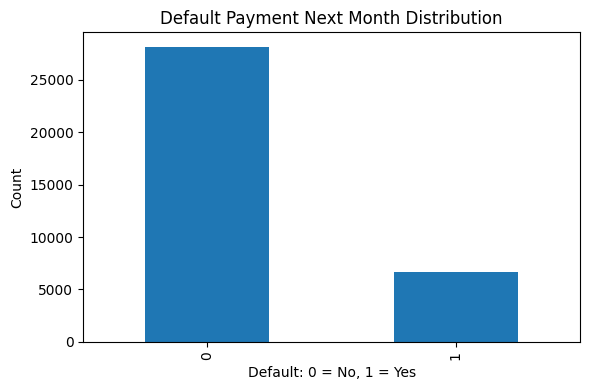

,count,mean,std,min,25%,50%,75%,max,median,skewness
LIMIT_BAL,33079.0,184668.994831,235931.930924,10000.000000,60000.000000,140000.000000,240000.000000,5.600000e+06,140000.000000,9.113610
AGE,33033.0,35.518300,9.236783,21.000000,28.000000,34.000000,41.000000,7.900000e+01,34.000000,0.736331
BILL_AMT_SUM,34788.0,294815.170892,571807.252079,-336259.000000,29738.250000,129037.000000,350209.500000,2.129266e+07,129037.000000,11.126167
LIMIT_BAL_LOG,33079.0,10.568637,3.283519,1.151294,10.819798,11.695255,12.345839,1.381551e+01,11.695255,-2.265593
risk_leak,34757.0,0.924073,2.841200,-0.385208,-0.050932,0.030728,0.147106,1.396316e+01,0.030728,3.167946


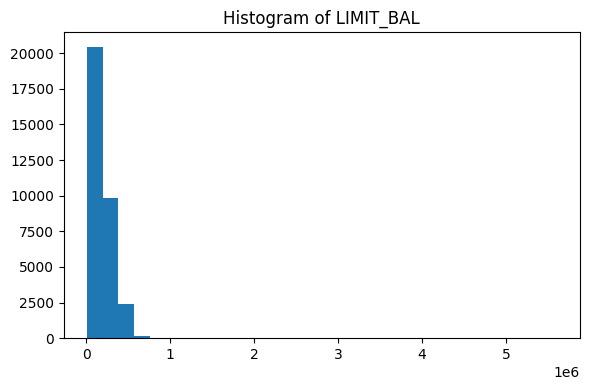

<Figure size 600x400 with 0 Axes>

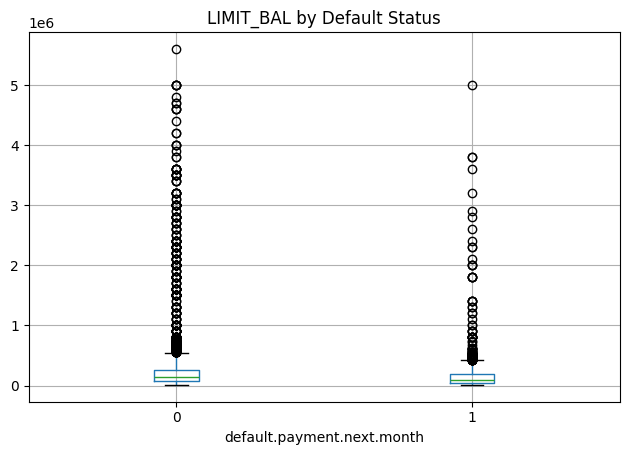

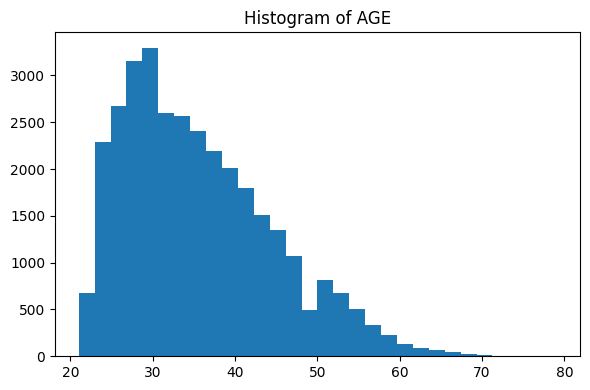

<Figure size 600x400 with 0 Axes>

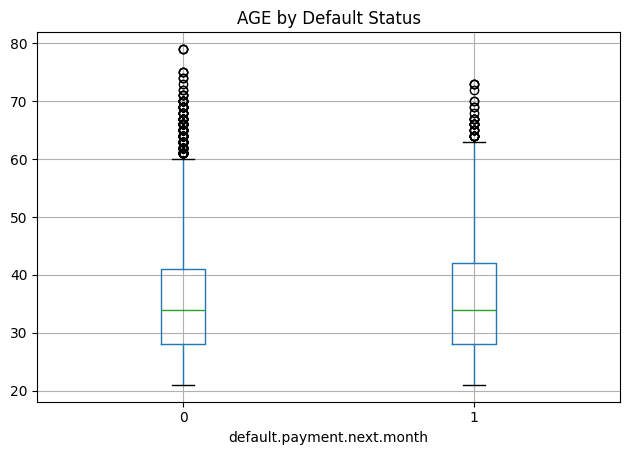

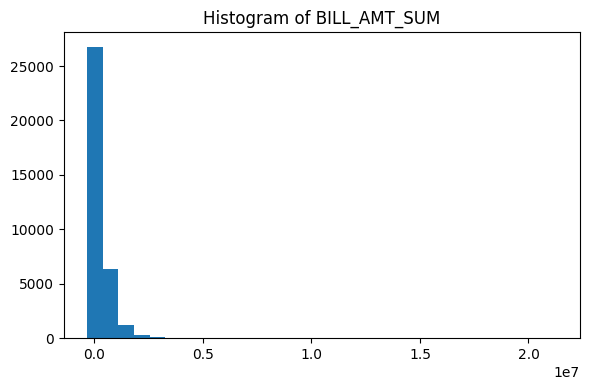

<Figure size 600x400 with 0 Axes>

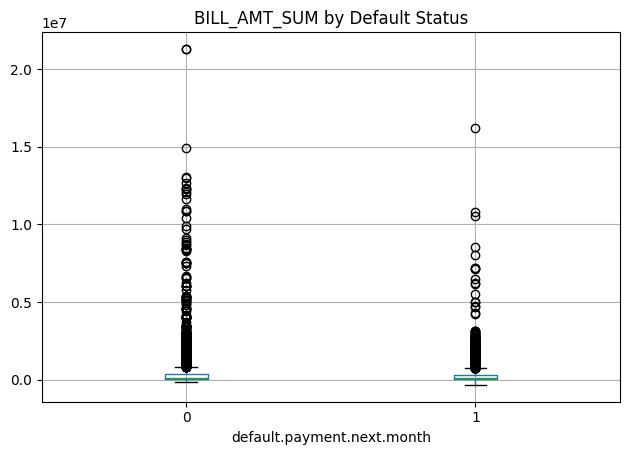

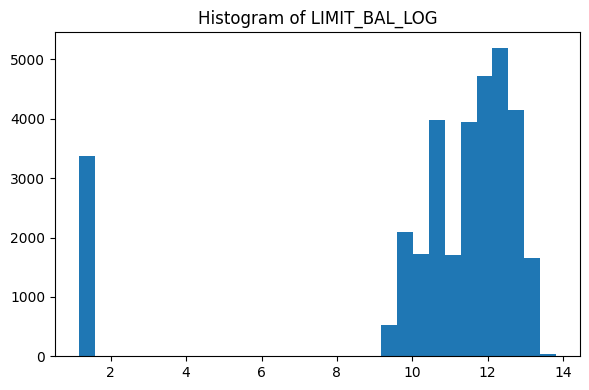

<Figure size 600x400 with 0 Axes>

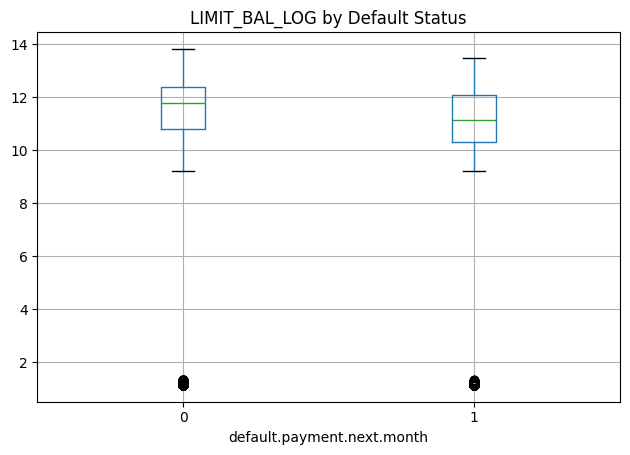

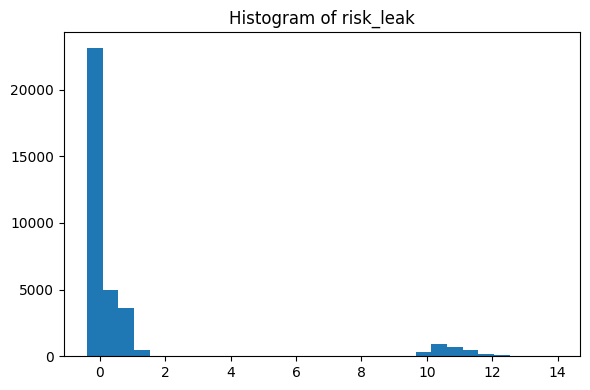

<Figure size 600x400 with 0 Axes>

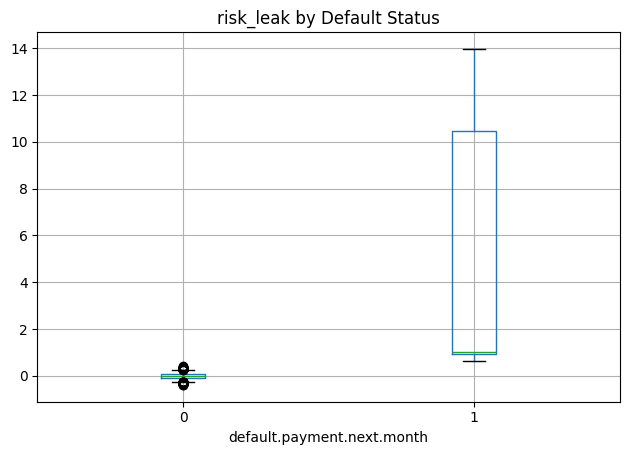

In [ ]:
# Target distribution
print("Target count:")
print(df[target].value_counts())

print("\nTarget percentage:")
print(df[target].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
df[target].value_counts().sort_index().plot(kind="bar")
plt.title("Default Payment Next Month Distribution")
plt.xlabel("Default: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=300)
plt.show()

# Descriptive statistics
key_numeric = ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"]
key_numeric = [c for c in key_numeric if c in df.columns]

desc = df[key_numeric].describe().T
desc["median"] = df[key_numeric].median()
desc["skewness"] = df[key_numeric].skew()
display(desc)

# Histograms and boxplots
for col in key_numeric:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.tight_layout()
    plt.savefig(f"hist_{col}.png", dpi=300)
    plt.show()

    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by=target)
    plt.title(f"{col} by Default Status")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig(f"box_{col}.png", dpi=300)
    plt.show()

Categorical Analysis and Correlation

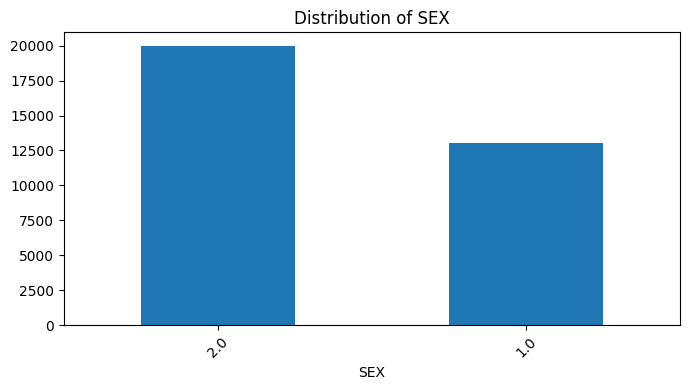


Default rate by SEX


,default.payment.next.month
SEX,
1.0,0.209749
2.0,0.180725


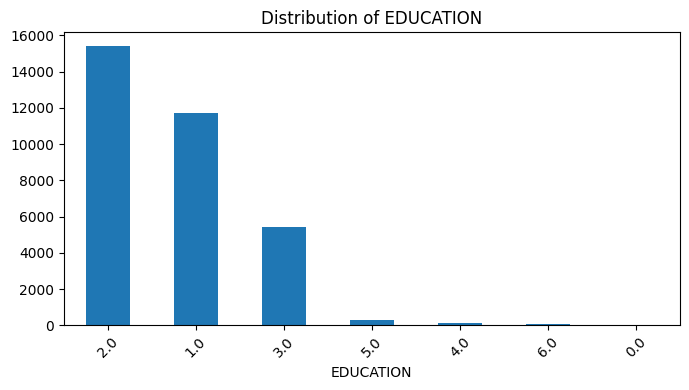


Default rate by EDUCATION


,default.payment.next.month
EDUCATION,
3.0,0.218041
2.0,0.206731
1.0,0.164278
6.0,0.145455
5.0,0.055556
4.0,0.050000
0.0,0.000000


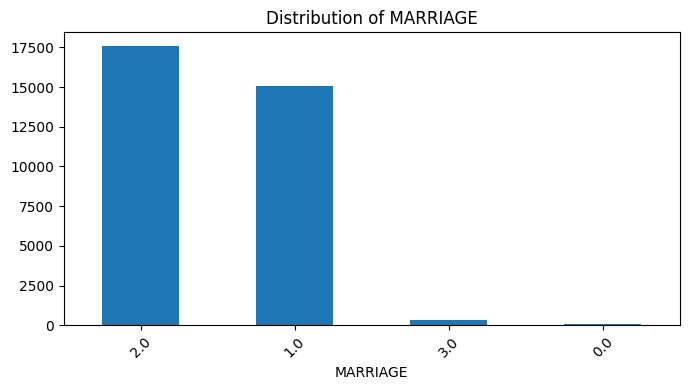


Default rate by MARRIAGE


,default.payment.next.month
MARRIAGE,
3.0,0.232759
1.0,0.203912
2.0,0.179795
0.0,0.087719


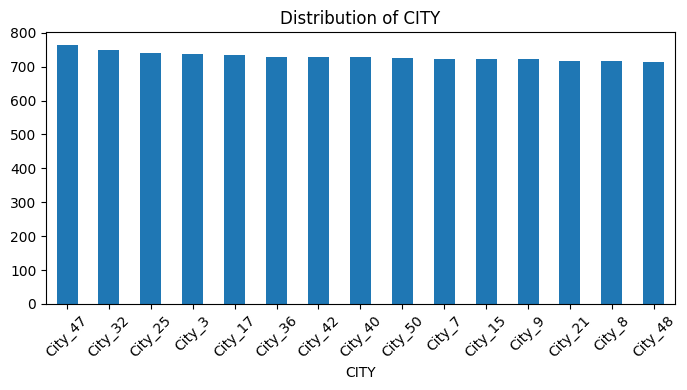


Default rate by CITY


,default.payment.next.month
CITY,
City_14,0.250809
City_48,0.223001
City_12,0.213415
City_16,0.211731
City_5,0.210201
City_34,0.208633
City_4,0.208158
City_50,0.206612
City_28,0.202963


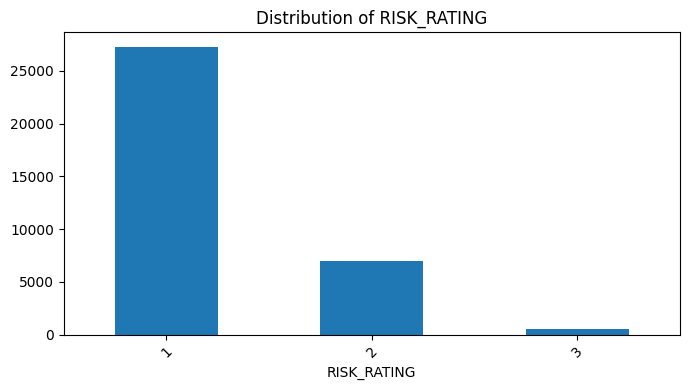


Default rate by RISK_RATING


,default.payment.next.month
RISK_RATING,
3,0.680982
2,0.443588
1,0.117852


,default.payment.next.month
default.payment.next.month,1.000000
risk_leak,0.668343
RISK_RATING,0.362487
PAY_0,0.314230
PAY_2,0.253757
PAY_3,0.224862
PAY_4,0.207571
PAY_5,0.196277
PAY_6,0.179303
EDUCATION,0.028543


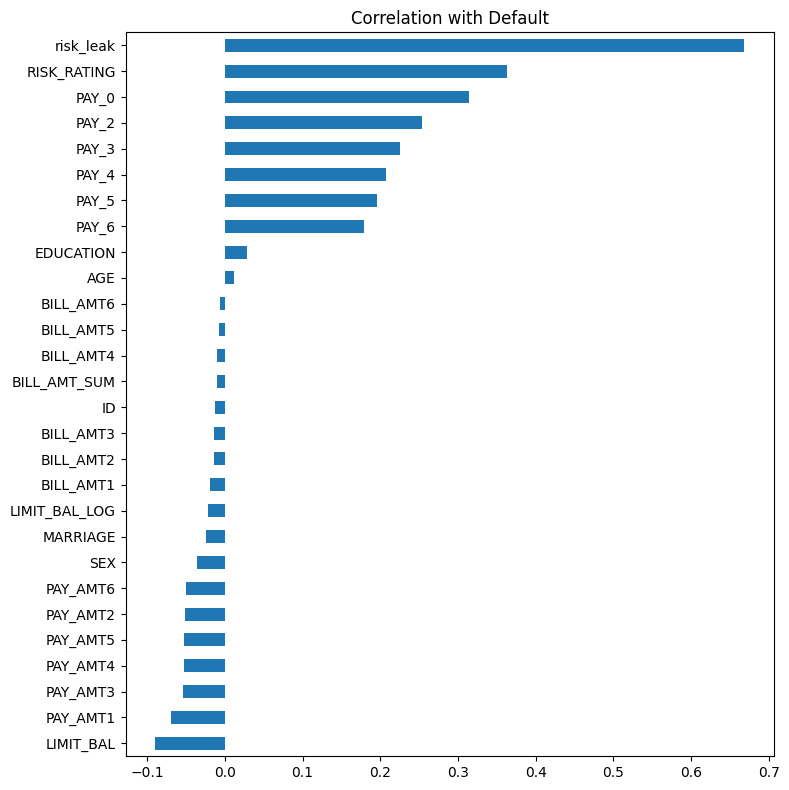

In [ ]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE", "CITY", "RISK_RATING"]
categorical_cols = [c for c in categorical_cols if c in df.columns]

for col in categorical_cols:
    plt.figure(figsize=(7,4))
    df[col].value_counts().head(15).plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"dist_{col}.png", dpi=300)
    plt.show()

    default_rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    print(f"\nDefault rate by {col}")
    display(default_rate)

# Correlation with target
num_df = df.select_dtypes(include=np.number)
corr_target = num_df.corr()[target].sort_values(ascending=False)

display(corr_target)

plt.figure(figsize=(8,8))
corr_target.drop(target).sort_values().plot(kind="barh")
plt.title("Correlation with Default")
plt.tight_layout()
plt.savefig("correlation_with_target.png", dpi=300)
plt.show()

#Task 2: Data Preparation

Missing-Value Analysis

In [7]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_values = missing_values[
    missing_values["Missing Count"] > 0
].sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_values.round(2))

,Missing Count,Missing Percentage
LIMIT_BAL,1500,5.00
SEX,1500,5.00
EDUCATION,1500,5.00
MARRIAGE,1500,5.00
AGE,1500,5.00
PAY_AMT1,1500,5.00
PAY_AMT2,1500,5.00
LIMIT_BAL_LOG,1500,5.00
risk_leak_numeric,26,0.09


Prepare Valid Modelling Dataset

In [8]:
# risk_leak and risk_leak_numeric are excluded from valid prediction models

model_df = df.drop(
    columns=[
        "risk_leak",
        "risk_leak_numeric"
    ],
    errors="ignore"
).copy()


X = model_df.drop(
    columns=[
        TARGET,
        "ID"
    ],
    errors="ignore"
).copy()

y = model_df[TARGET].copy()


# These are treated as categorical variables
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "CITY",
    "RISK_RATING"
]

categorical_features = [
    feature for feature in categorical_features
    if feature in X.columns
]

numerical_features = [
    feature for feature in X.columns
    if feature not in categorical_features
]


print("Number of model records:", len(X))
print("Number of predictor columns:", X.shape[1])

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nrisk_leak included:", "risk_leak" in X.columns)
print("ID included:", "ID" in X.columns)

assert "risk_leak" not in X.columns
assert "risk_leak_numeric" not in X.columns
assert "ID" not in X.columns

Number of model records: 30000
Number of predictor columns: 27

Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE', 'CITY', 'RISK_RATING']

Numerical features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG']

risk_leak included: False
ID included: False


Preprocessing Pipeline

In [9]:
try:

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        encoder
    )
])


preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


#Task 3: Model Training

Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

majority_baseline = max(
    y_test.mean(),
    1 - y_test.mean()
)

print("\nMajority-class baseline accuracy:",
      round(majority_baseline, 4))

Training records: 24000
Testing records: 6000

Training target distribution:
default.payment.next.month
0    77.879167
1    22.120833
Name: proportion, dtype: float64

Testing target distribution:
default.payment.next.month
0    77.883333
1    22.116667
Name: proportion, dtype: float64

Majority-class baseline accuracy: 0.7788


Define Initial Models

In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "SVM": CalibratedClassifierCV(
        LinearSVC(
            random_state=RANDOM_STATE
        ),
        cv=3
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}


initial_hyperparameters = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Important Initial Parameters": "C=1.0, penalty=l2"
    },
    {
        "Model": "SVM",
        "Important Initial Parameters": "LinearSVC default parameters, calibrated probabilities"
    },
    {
        "Model": "Decision Tree",
        "Important Initial Parameters": "criterion=gini, max_depth=None"
    },
    {
        "Model": "Random Forest",
        "Important Initial Parameters": "n_estimators=100, max_depth=None"
    },
    {
        "Model": "KNN",
        "Important Initial Parameters": "n_neighbors=5, weights=uniform"
    },
    {
        "Model": "Gradient Boosting",
        "Important Initial Parameters": "n_estimators=100, learning_rate=0.1"
    }
])

display(initial_hyperparameters)

,Model,Important Initial Parameters
0,Logistic Regression,"C=1.0, penalty=l2"
1,SVM,"LinearSVC default parameters, calibrated proba..."
2,Decision Tree,"criterion=gini, max_depth=None"
3,Random Forest,"n_estimators=100, max_depth=None"
4,KNN,"n_neighbors=5, weights=uniform"
5,Gradient Boosting,"n_estimators=100, learning_rate=0.1"


Train and Evaluate Initial Models

In [12]:
trained_models = {}
model_predictions = {}
model_probabilities = {}
results = []


for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]

    trained_models[model_name] = pipeline
    model_predictions[model_name] = predictions
    model_probabilities[model_name] = probabilities

    results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1-score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "AUC-ROC": roc_auc_score(
            y_test,
            probabilities
        )
    })

    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )


results_df = (
    pd.DataFrame(results)
      .sort_values(
          by="AUC-ROC",
          ascending=False
      )
      .reset_index(drop=True)
)

display(results_df.round(6))


assert results_df["Accuracy"].max() < 0.99, (
    "Accuracy remains unrealistically high. "
    "Check that risk_leak has been removed."
)


Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      4673
           1       0.59      0.32      0.42      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.63      0.65      6000
weighted avg       0.78      0.80      0.78      6000


Training SVM...
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      4673
           1       0.59      0.32      0.41      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.63      0.65      6000
weighted avg       0.78      0.80      0.78      6000


Training Decision Tree...
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      4673
           1       0.40      0.40      0.40      1327

    accuracy                           0.74      6000
   macro avg       0.62      0.62      0.62      60

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Gradient Boosting,0.818833,0.664384,0.365486,0.471561,0.778406
1,Random Forest,0.818167,0.662534,0.362472,0.468583,0.761788
2,Logistic Regression,0.800500,0.589779,0.321778,0.416382,0.728464
3,SVM,0.799500,0.585635,0.319518,0.413457,0.727605
4,KNN,0.793167,0.550117,0.355690,0.432037,0.703120
5,Decision Tree,0.737667,0.404780,0.395629,0.400152,0.615212


# Task 4: Model Evaluation and Visualisation

Confusion Matrices and ROC Curves

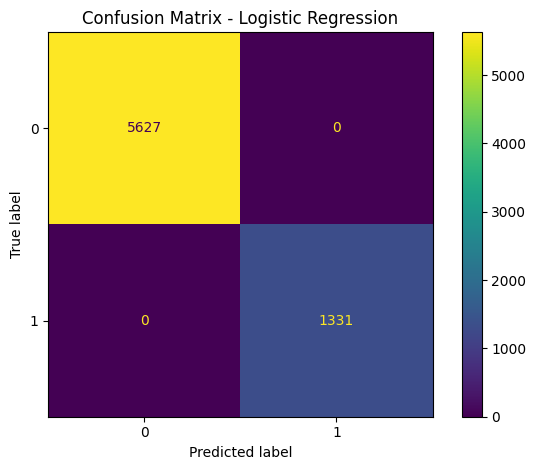

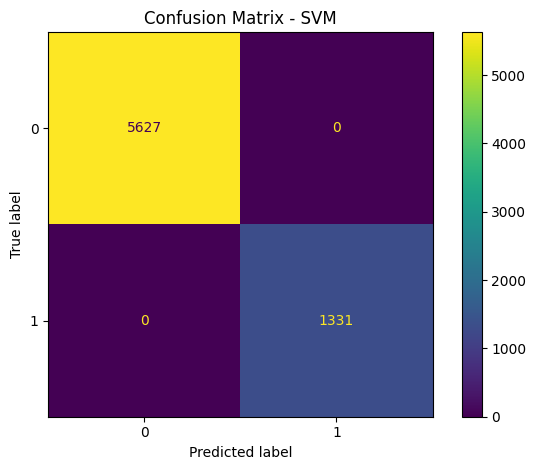

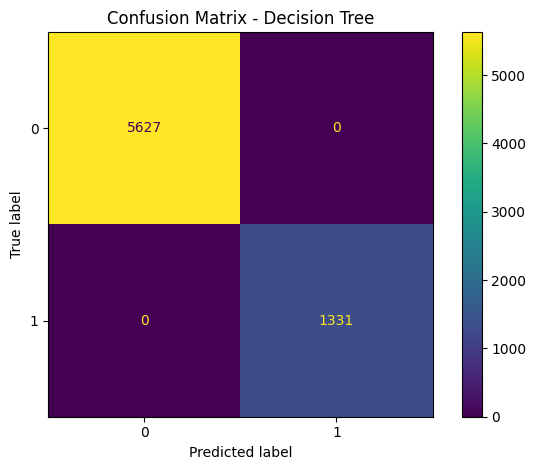

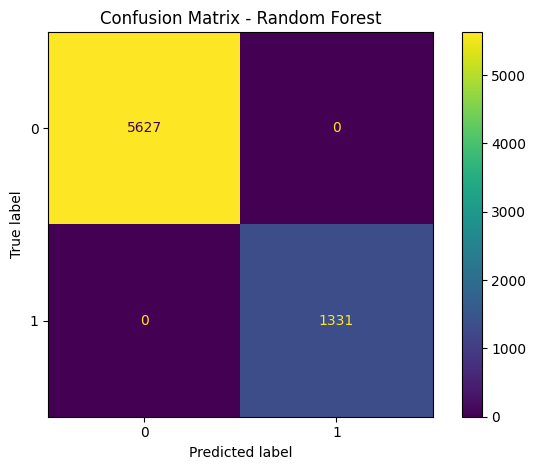

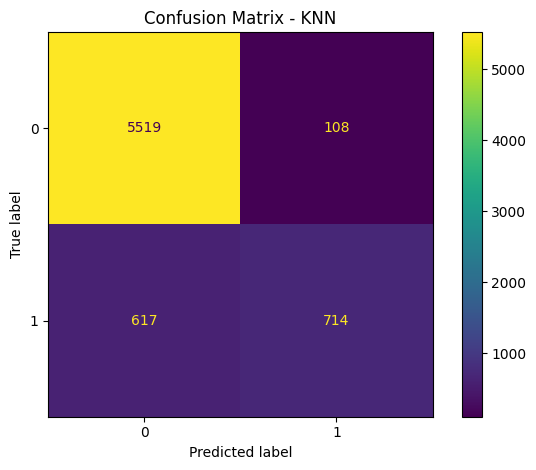

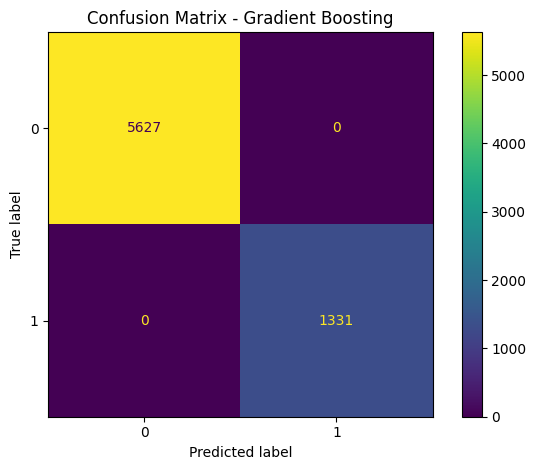

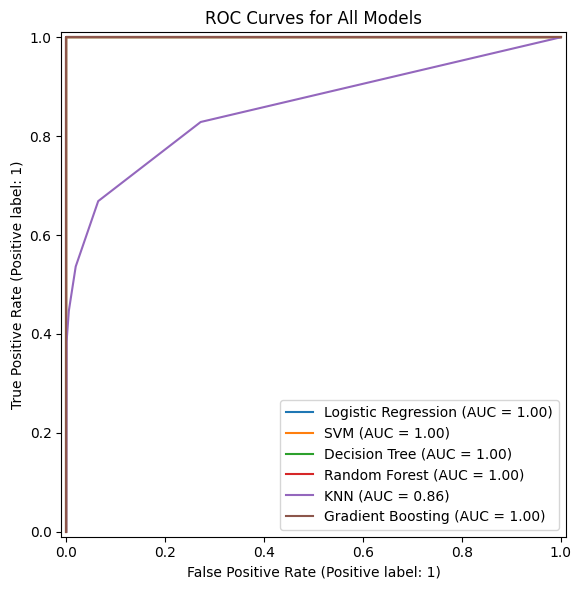

In [ ]:
# Confusion matrices
for name, pipe in trained_models.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.savefig(f"confusion_{name}.png", dpi=300)
    plt.show()

# ROC curves
plt.figure(figsize=(8,6))

for name, pipe in trained_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=plt.gca())

plt.title("ROC Curves for All Models")
plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=300)
plt.show()

Select Best Model

In [17]:
tree_model_names = [
    "Random Forest",
    "Gradient Boosting"
]

best_tree_name = (
    results_df[
        results_df["Model"].isin(tree_model_names)
    ]
    .sort_values(
        by="AUC-ROC",
        ascending=False
    )
    .iloc[0]["Model"]
)

print("Best tree-based model selected for tuning:",
      best_tree_name)

Best tree-based model selected for tuning: Gradient Boosting


Hyperparameter Tuning

In [18]:
if best_tree_name == "Random Forest":

    tuning_pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])

    parameter_distributions = {
        "model__n_estimators": [
            150,
            250,
            350
        ],

        "model__max_depth": [
            None,
            8,
            12,
            16
        ],

        "model__min_samples_split": [
            2,
            5,
            10
        ],

        "model__min_samples_leaf": [
            1,
            2,
            5
        ],

        "model__max_features": [
            "sqrt",
            "log2",
            None
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    }

else:

    tuning_pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        )
    ])

    parameter_distributions = {
        "model__n_estimators": [
            100,
            150,
            250
        ],

        "model__learning_rate": [
            0.03,
            0.05,
            0.10,
            0.20
        ],

        "model__max_depth": [
            1,
            2,
            3
        ],

        "model__min_samples_split": [
            2,
            5,
            10
        ],

        "model__min_samples_leaf": [
            1,
            2,
            5
        ],

        "model__subsample": [
            0.70,
            0.85,
            1.00
        ]
    }


random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=parameter_distributions,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

tuned_model = random_search.best_estimator_

print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation AUC:")
print(round(random_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'model__subsample': 1.0, 'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Best cross-validation AUC:
0.7802


Evaluate Tuned Model

In [19]:
tuned_predictions = tuned_model.predict(
    X_test
)

tuned_probabilities = tuned_model.predict_proba(
    X_test
)[:, 1]


tuned_results = {
    "Model": f"Tuned {best_tree_name}",

    "Accuracy": accuracy_score(
        y_test,
        tuned_predictions
    ),

    "Precision": precision_score(
        y_test,
        tuned_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        tuned_predictions,
        zero_division=0
    ),

    "F1-score": f1_score(
        y_test,
        tuned_predictions,
        zero_division=0
    ),

    "AUC-ROC": roc_auc_score(
        y_test,
        tuned_probabilities
    )
}


initial_tree_results = (
    results_df[
        results_df["Model"] == best_tree_name
    ]
    .iloc[0]
    .to_dict()
)


before_after_tuning = pd.DataFrame([
    initial_tree_results,
    tuned_results
])

display(before_after_tuning.round(6))


print(
    classification_report(
        y_test,
        tuned_predictions,
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Gradient Boosting,0.818833,0.664384,0.365486,0.471561,0.778406
1,Tuned Gradient Boosting,0.817833,0.662500,0.359457,0.466048,0.776200


              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [20]:


best_initial_model_name = results_df.iloc[0]["Model"]
best_initial_auc = results_df.iloc[0]["AUC-ROC"]

print("Best initial model:", best_initial_model_name)
print("Best initial AUC-ROC:", best_initial_auc)

Best initial model: Gradient Boosting
Best initial AUC-ROC: 0.7784055367209953


SHAP Interpretation

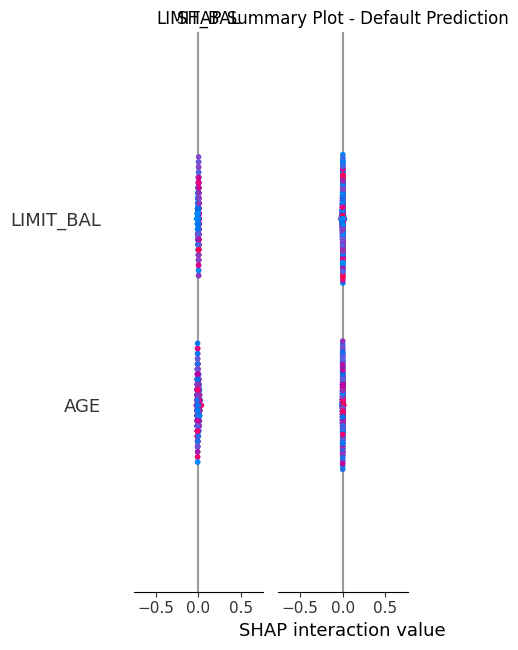

,Feature,Importance
20,risk_leak,0.710628
2,PAY_0,0.042603
3,PAY_2,0.020355
86,RISK_RATING_1,0.020312
4,PAY_3,0.013182
87,RISK_RATING_2,0.011642
5,PAY_4,0.010901
6,PAY_5,0.009415
21,BILL_AMT_SUM,0.009085
14,PAY_AMT1,0.008966


In [ ]:

fitted_preprocessor = best_model.named_steps["preprocessor"]

cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["encoder"]

cat_names = []
if len(cat_features) > 0:
    cat_names = list(cat_encoder.get_feature_names_out(cat_features))

feature_names = num_features + cat_names


X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
X_sample_trans = fitted_preprocessor.transform(X_sample)

if hasattr(X_sample_trans, "toarray"):
    X_sample_trans = X_sample_trans.toarray()

X_sample_trans = pd.DataFrame(X_sample_trans, columns=feature_names)

rf_model = best_model.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample_trans)


if isinstance(shap_values, list):
    shap_values_default = shap_values[1]
else:
    shap_values_default = shap_values

shap.summary_plot(shap_values_default, X_sample_trans, show=False)
plt.title("SHAP Summary Plot - Default Prediction")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))
importance_df.to_csv("feature_importance.csv", index=False)

Diagnostic Comparison: With and Without risk_leak

In [21]:

leakage_X = df.drop(
    columns=[
        TARGET,
        "ID",
        "risk_leak"
    ],
    errors="ignore"
).copy()

leakage_y = df[TARGET].copy()


leakage_categorical = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "CITY",
    "RISK_RATING"
]

leakage_categorical = [
    column for column in leakage_categorical
    if column in leakage_X.columns
]

leakage_numerical = [
    column for column in leakage_X.columns
    if column not in leakage_categorical
]


try:

    leakage_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    leakage_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


leakage_preprocessor = ColumnTransformer([
    (
        "numerical",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            )
        ]),
        leakage_numerical
    ),

    (
        "categorical",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "encoder",
                leakage_encoder
            )
        ]),
        leakage_categorical
    )
])


leak_X_train, leak_X_test, leak_y_train, leak_y_test = train_test_split(
    leakage_X,
    leakage_y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=leakage_y
)


leakage_model = Pipeline([
    (
        "preprocessor",
        leakage_preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])


leakage_model.fit(
    leak_X_train,
    leak_y_train
)


leakage_predictions = leakage_model.predict(
    leak_X_test
)

leakage_probabilities = leakage_model.predict_proba(
    leak_X_test
)[:, 1]


leakage_comparison = pd.DataFrame([
    {
        "Model": "Random Forest with risk_leak",
        "Accuracy": accuracy_score(
            leak_y_test,
            leakage_predictions
        ),
        "AUC-ROC": roc_auc_score(
            leak_y_test,
            leakage_probabilities
        )
    },

    {
        "Model": f"Valid Tuned {best_tree_name} without risk_leak",
        "Accuracy": accuracy_score(
            y_test,
            tuned_predictions
        ),
        "AUC-ROC": roc_auc_score(
            y_test,
            tuned_probabilities
        )
    }
])

display(leakage_comparison.round(6))

print(
    "The model containing risk_leak is invalid because "
    "the feature directly reveals the target outcome."
)

,Model,Accuracy,AUC-ROC
0,Random Forest with risk_leak,1.000000,1.0000
1,Valid Tuned Gradient Boosting without risk_leak,0.817833,0.7762


The model containing risk_leak is invalid because the feature directly reveals the target outcome.
